In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Disorder Aggregation

To align subject-level neuroimaging and phenomic representations with disorder-level genomic embeddings, we performed disorder-level aggregation. For each disorder category (ADHD, ASD, Dyslexia, and Control), individual embeddings were averaged using mean pooling to obtain a single representative vector. This aggregation produced a disorder-level representation that summarizes the characteristic patterns of each condition while reducing noise from individual variability.

## Apply on sMRI Embeddings

In [32]:
X_sMRI_train = np.load(r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Extracting embeddings\sMRI_resnet_train_embeddings.npy")
X_sMRI_test  = np.load(r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Extracting embeddings\sMRI_resnet_test_embeddings.npy")

y_sMRI_train = np.load(r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Extracting embeddings\sMRI_resnet_train_labels.npy")
y_sMRI_test  = np.load(r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Extracting embeddings\sMRI_resnet_test_labels.npy")

print("Train embeddings:", X_sMRI_train.shape)
print("Test embeddings :", X_sMRI_test.shape)


Train embeddings: (2004, 128)
Test embeddings : (502, 128)


In [33]:
y_sMRI_train

array([3, 2, 2, ..., 2, 1, 1], shape=(2004,))

In [34]:
scaler = StandardScaler()

X_sMRI_train = scaler.fit_transform(X_sMRI_train)
X_sMRI_test = scaler.transform(X_sMRI_test)

In [35]:
def disorder_aggregation(X, y):

    df = pd.DataFrame(X)
    df["label"] = y

    agg_df = df.groupby("label").mean()

    agg_vectors = agg_df.values
    agg_labels = agg_df.index.tolist()
    print(agg_labels)

    return agg_vectors, agg_labels

In [36]:
# Train aggregation
smri_train_vectors, smri_train_labels = disorder_aggregation(
    X_sMRI_train,
    y_sMRI_train
)

# Test aggregation
smri_test_vectors, smri_test_labels = disorder_aggregation(
    X_sMRI_test,
    y_sMRI_test
)

[0, 1, 2, 3]
[0, 1, 2, 3]


In [37]:
print("sMRI Train Embeddings shape (Aggregated): ", smri_train_vectors.shape)
print("sMRI Test Embeddings shape (Aggregated): ", smri_test_vectors.shape)

sMRI Train Embeddings shape (Aggregated):  (4, 128)
sMRI Test Embeddings shape (Aggregated):  (4, 128)


## Apply on Phenomic Embeddings

In [38]:
X_phenomic_train = np.load(r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Extracting embeddings\phenomic_train_embeddings.npy")
X_phenomic_test  = np.load(r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Extracting embeddings\phenomic_test_embeddings.npy")

y_phenomic_train = np.load(r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Extracting embeddings\phenomic_train_labels.npy")
y_phenomic_test  = np.load(r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Extracting embeddings\phenomic_test_labels.npy")

print("Train embeddings:", X_phenomic_train.shape)
print("Test embeddings :", X_phenomic_test.shape)


Train embeddings: (1664, 128)
Test embeddings : (417, 128)


In [39]:
X_phenomic_train = scaler.fit_transform(X_phenomic_train)
X_phenomic_test = scaler.transform(X_phenomic_test)

In [40]:
# Convert one hot labels to class labels
y_phenomic_train_labels = np.argmax(y_phenomic_train, axis=1)
y_phenomic_test_labels  = np.argmax(y_phenomic_test, axis=1)

In [41]:
# Train aggregation
phenomic_train_vectors, phenomic_train_labels = disorder_aggregation(
    X_phenomic_train,
    y_phenomic_train_labels
)

# Test aggregation
phenomic_test_vectors, phenomic_test_labels = disorder_aggregation(
    X_phenomic_test,
    y_phenomic_test_labels
)

[0, 1, 2, 3]
[0, 1, 2, 3]


In [42]:
print("Phenomic Train Embeddings shape (Aggregated): ", phenomic_train_vectors.shape)
print("Phenomic Test Embeddings shape (Aggregated): ", phenomic_test_vectors.shape)

Phenomic Train Embeddings shape (Aggregated):  (4, 128)
Phenomic Test Embeddings shape (Aggregated):  (4, 128)


In [43]:
# Check if disorder order matches across all modalities
print(phenomic_train_labels)
print(phenomic_test_labels)
print(smri_train_labels)
print(smri_test_labels)

[0, 1, 2, 3]
[0, 1, 2, 3]
[0, 1, 2, 3]
[0, 1, 2, 3]


The disorder order matches

# Align with Genetic Embeddings

In [44]:
genomic_embeddings = np.load(
    r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Extracting embeddings\genomic_embeddings.npy"
)

genomic_labels = np.load(
    r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Implementation\Extracting embeddings\genomic_labels.npy",
    allow_pickle=True  # <- add this
)

print("Genomic embeddings shape:", genomic_embeddings.shape)
print("Genomic labels:", genomic_labels)

Genomic embeddings shape: (3, 128)
Genomic labels: ['ADHD' 'ASD' 'Dyslexia']


In [45]:
control_vector = np.zeros((1, 128))  # same embedding dimension
genomic_embeddings = np.vstack([genomic_embeddings[:2], control_vector, genomic_embeddings[2:]])

In [46]:
print("sMRI train labels:", smri_train_labels)
print("Phenomic train labels:", phenomic_train_labels)
print("Genomic labels: ['ADHD','ASD','Control','Dyslexia']")

sMRI train labels: [0, 1, 2, 3]
Phenomic train labels: [0, 1, 2, 3]
Genomic labels: ['ADHD','ASD','Control','Dyslexia']


In [47]:
# Define the disorder mapping
disorder_map = {
    0: 'ADHD',
    1: 'ASD',
    2: 'Control',
    3: 'Dyslexia'
}

# Function to print numeric labels and their disorder names
def print_label_mapping(labels, modality_name="Modality"):
    print(f"\n{modality_name} label mapping:")
    for idx in labels:
        disorder_name = disorder_map.get(idx, "Unknown")
        print(f"Label {idx} → {disorder_name}")

# Example usage
print_label_mapping(smri_train_labels, "sMRI Train")
print_label_mapping(phenomic_train_labels, "Phenomic Train")
print_label_mapping([0, 1, 2, 3], "Genomic")  # since genomic_embeddings are aligned manually


sMRI Train label mapping:
Label 0 → ADHD
Label 1 → ASD
Label 2 → Control
Label 3 → Dyslexia

Phenomic Train label mapping:
Label 0 → ADHD
Label 1 → ASD
Label 2 → Control
Label 3 → Dyslexia

Genomic label mapping:
Label 0 → ADHD
Label 1 → ASD
Label 2 → Control
Label 3 → Dyslexia


### Prepare Inputs for Attention Fusion

In [48]:
# 3 modalities x 4 disorders x 128 embedding dim
smri = smri_train_vectors      # (4, 128)
phenomic = phenomic_train_vectors  # (4, 128)
genomic = genomic_embeddings       # (4, 128)

# Stack modalities as sequence dimension
fusion_input = np.stack([smri, phenomic, genomic], axis=1)  
# Shape: (num_disorders=4, num_modalities=3, embedding_dim=128)

## Cross modal attention on train data

In [49]:
import numpy as np
import torch
import torch.nn as nn

In [50]:
fusion_input = np.stack([smri_train_vectors,
                         phenomic_train_vectors,
                         genomic_embeddings], axis=1)

fusion_input_tensor = torch.tensor(fusion_input, dtype=torch.float32)  # (4,3,128)

In [51]:
# Cross-Modal Attention Module
class CrossModalAttentionFusion(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.fusion_pool = nn.Linear(embed_dim, embed_dim)
    
    def forward(self, x):
        # x: (num_disorders, num_modalities, embed_dim)
        attn_out, attn_weights = self.attention(x, x, x)  # Self-attention across modalities
        # Pool modality dimension to get a single embedding per disorder
        fused = attn_out.mean(dim=1)  # Shape: (num_disorders, embed_dim)
        fused = self.fusion_pool(fused)  # Optional: Linear layer to refine fused embedding
        return fused, attn_weights

In [52]:
# Instantiate and run fusion
fusion_model = CrossModalAttentionFusion(embed_dim=128, num_heads=4)
fused_embeddings, attn_weights = fusion_model(fusion_input_tensor)

In [53]:
print("Fused embeddings shape:", fused_embeddings.shape)
print("Attention weights shape:", attn_weights.shape)

np.save("fused_embeddings.npy", fused_embeddings.detach().numpy())

Fused embeddings shape: torch.Size([4, 128])
Attention weights shape: torch.Size([4, 3, 3])


## Cross modal attention on train data

In [54]:
# Prepare test fusion input

smri_test = smri_test_vectors
phenomic_test = phenomic_test_vectors

In [55]:
# genomic embeddings are the same
genomic_test = genomic_embeddings

fusion_test_input = np.stack([
    smri_test,
    phenomic_test,
    genomic_test
], axis=1)

In [56]:
fusion_test_tensor = torch.tensor(fusion_test_input, dtype=torch.float32)

In [58]:
# Apply the same fusion model
fusion_model.eval()

with torch.no_grad():
    fused_test_embeddings, test_attn_weights = fusion_model(fusion_test_tensor)

In [62]:
print("Test fused embeddings shape:", fused_test_embeddings.shape)
print("Test attention weights shape:", test_attn_weights.shape)
np.save("fused_test_embeddings.npy", fused_embeddings.detach().numpy())

Test fused embeddings shape: torch.Size([4, 128])
Test attention weights shape: torch.Size([4, 3, 3])


### Attention Matrix for each disorder to check how each modality has contributed to each disorder

In [63]:
modalities = ['sMRI', 'Phenomic', 'Genomic']
num_disorders = attn_weights.shape[0]  # e.g., 4
disorder_labels = ["ADHD", "ASD", "Control", "Dyslexia"]

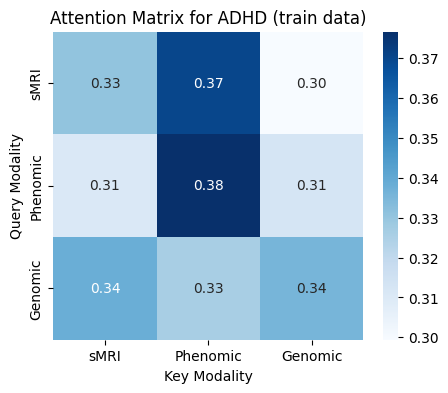

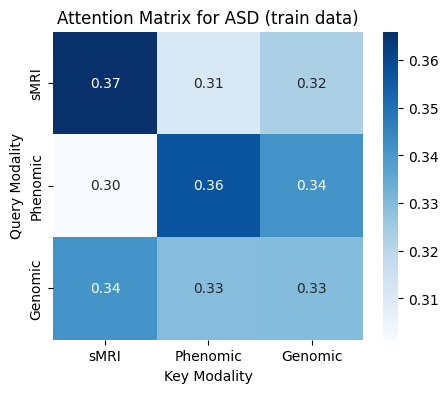

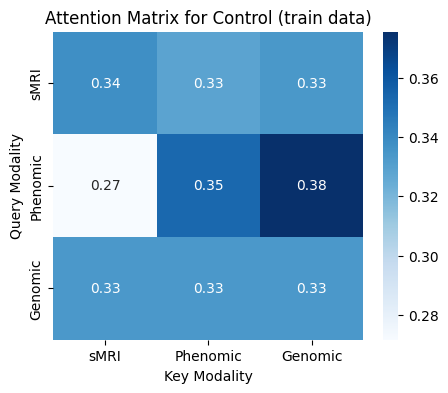

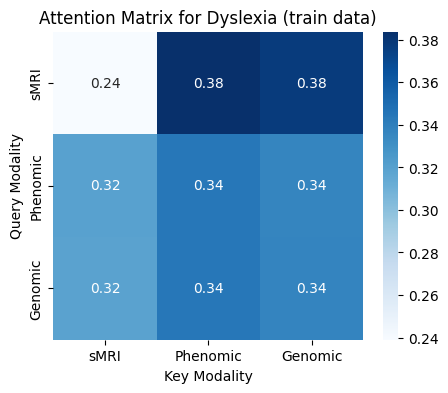

In [64]:
for i in range(num_disorders):
    plt.figure(figsize=(5,4))
    
    # Detach and convert to numpy
    heatmap_data = attn_weights[i].detach().cpu().numpy() if hasattr(attn_weights[i], 'detach') else attn_weights[i]
    
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        xticklabels=modalities,
        yticklabels=modalities,
        cmap="Blues"
    )
    
    plt.title(f"Attention Matrix for {disorder_labels[i]} (train data)")
    plt.xlabel("Key Modality")
    plt.ylabel("Query Modality")
    plt.show()